In [1]:

from google.colab import drive
drive.mount('/content/drive',force_remount=True )
import sys
sys.path.append('/content/drive/My Drive/models/helper')


Mounted at /content/drive


In [2]:
from helper_dataset import get_dataloaders_mnist
from helper_evaluation import set_all_seeds, set_deterministic
from helper_train import train_model,train_autoencoder
from helper_plotting import plot_training_loss, plot_accuracy, show_examples, plot_latent_space_with_labels, plot_generated_images

import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [4]:

train_loader, valid_loader, test_loader = get_dataloaders_mnist(
    batch_size=256,
    num_workers=2,
    validation_fraction=0.)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.30MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.94MB/s]


In [25]:
class Reshape(torch.nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.shape = args

    def forward(self, x):
        return x.view(self.shape)

#in video tuttorial
# class Trim(torch.nn.Module):
#     def __init__(self, *args):
#         super().__init__()

#     def forward(self, x):
#         return x[:, :, :28, :28]


class AutoEncoder(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = torch.nn.Sequential(
                torch.nn.Conv2d(1, 32, stride=(1, 1), kernel_size=(3, 3), padding=1),
                torch.nn.LeakyReLU(0.01),
                torch.nn.Conv2d(32, 64, stride=(2, 2), kernel_size=(3, 3), padding=1),
                torch.nn.LeakyReLU(0.01),
                torch.nn.Conv2d(64, 64, stride=(2, 2), kernel_size=(3, 3), padding=1),
                torch.nn.LeakyReLU(0.01),
                torch.nn.Conv2d(64, 64, stride=(1, 1), kernel_size=(3, 3), padding=1),
                torch.nn.Flatten(),
                torch.nn.Linear(3136, 2) # here the size of image reduces to 7x7 after applying filter
        )
        # self.decoder = torch.nn.Sequential(
        #         torch.nn.Linear(2, 3136),
        #         Reshape(-1, 64, 7, 7),
        #         torch.nn.ConvTranspose2d(64, 64, stride=(1, 1), kernel_size=(3, 3), padding=1),
        #         torch.nn.LeakyReLU(0.01),
        #         torch.nn.ConvTranspose2d(64, 64, stride=(2, 2), kernel_size=(3, 3), padding=1),
        #         torch.nn.LeakyReLU(0.01),
        #         torch.nn.ConvTranspose2d(64, 32, stride=(2, 2), kernel_size=(3, 3), padding=0),
        #         torch.nn.LeakyReLU(0.01),
        #         torch.nn.ConvTranspose2d(32, 1, stride=(1, 1), kernel_size=(3, 3), padding=0),
        #         Trim(),  # 1x29x29 -> 1x28x28
        #         torch.nn.Sigmoid()
        #         )

        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(2, 3136),
            # torch.nn.LeakyReLU(0.01),
            torch.nn.Unflatten(1,(64,7,7)),
            torch.nn.ConvTranspose2d(64, 64, stride=(1, 1), kernel_size=(3, 3), padding=1),
            torch.nn.LeakyReLU(0.01),
            torch.nn.ConvTranspose2d(64, 64, stride=(2, 2), kernel_size=(3, 3), padding=1,output_padding=1),
            torch.nn.LeakyReLU(0.01),
            torch.nn.ConvTranspose2d(64, 32, stride=(2, 2), kernel_size=(3, 3), padding=1,output_padding=1),
            torch.nn.LeakyReLU(0.01),
            torch.nn.ConvTranspose2d(32, 1, stride=(1, 1), kernel_size=(3, 3), padding=1),
            torch.nn.Sigmoid()
            )




    def forward(self, x):
        x = self.encoder(x)
        # print("1: ",x.shape)
        x = self.decoder(x)
        # print("2: ",x.shape)

        return x

In [26]:
set_all_seeds(42)

model = AutoEncoder()
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [27]:
log_dict = train_autoencoder(num_epochs=20, model=model,
                                optimizer=optimizer, device=device,
                                train_loader=train_loader,
                                skip_epoch_stats=True,
                                logging_interval=100)

Epoch: 001/020 | Batch 0000/0234 | Loss: 0.2014
Epoch: 001/020 | Batch 0100/0234 | Loss: 0.0659
Epoch: 001/020 | Batch 0200/0234 | Loss: 0.0598
Time elapsed: 0.15 min
Epoch: 002/020 | Batch 0000/0234 | Loss: 0.0524
Epoch: 002/020 | Batch 0100/0234 | Loss: 0.0519
Epoch: 002/020 | Batch 0200/0234 | Loss: 0.0498
Time elapsed: 0.32 min
Epoch: 003/020 | Batch 0000/0234 | Loss: 0.0506
Epoch: 003/020 | Batch 0100/0234 | Loss: 0.0468
Epoch: 003/020 | Batch 0200/0234 | Loss: 0.0490
Time elapsed: 0.47 min
Epoch: 004/020 | Batch 0000/0234 | Loss: 0.0466
Epoch: 004/020 | Batch 0100/0234 | Loss: 0.0462
Epoch: 004/020 | Batch 0200/0234 | Loss: 0.0455
Time elapsed: 0.62 min
Epoch: 005/020 | Batch 0000/0234 | Loss: 0.0482
Epoch: 005/020 | Batch 0100/0234 | Loss: 0.0459
Epoch: 005/020 | Batch 0200/0234 | Loss: 0.0456
Time elapsed: 0.77 min
Epoch: 006/020 | Batch 0000/0234 | Loss: 0.0451
Epoch: 006/020 | Batch 0100/0234 | Loss: 0.0447
Epoch: 006/020 | Batch 0200/0234 | Loss: 0.0445
Time elapsed: 0.93 mi

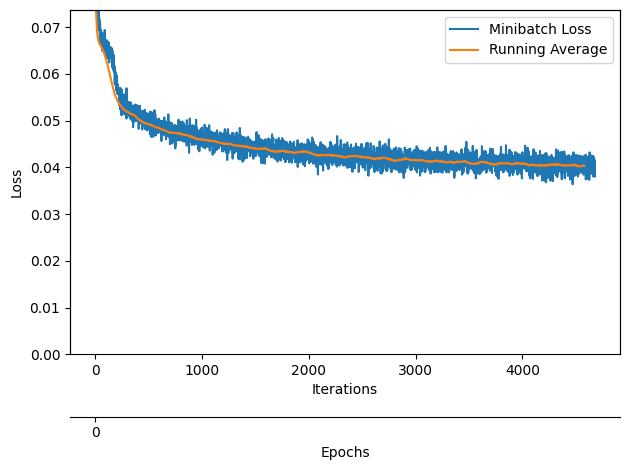

In [28]:
plot_training_loss(log_dict['train_loss_per_batch'], 5,3)
plt.show()

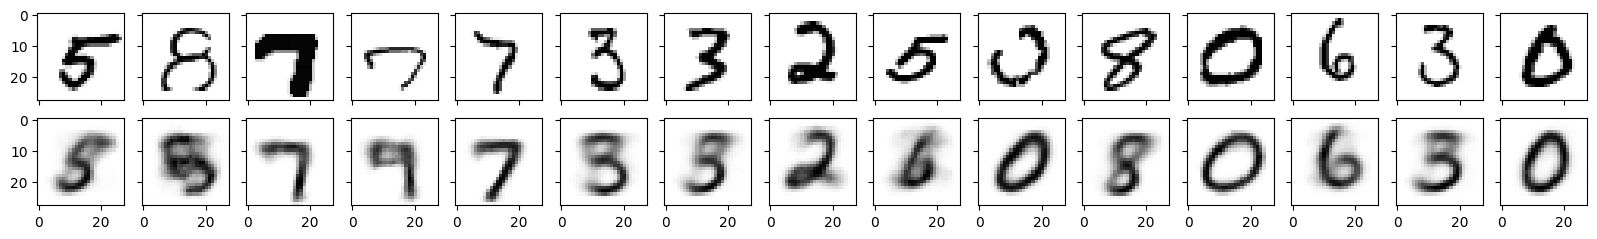

In [33]:
plot_generated_images(data_loader=train_loader, model=model, device=device)

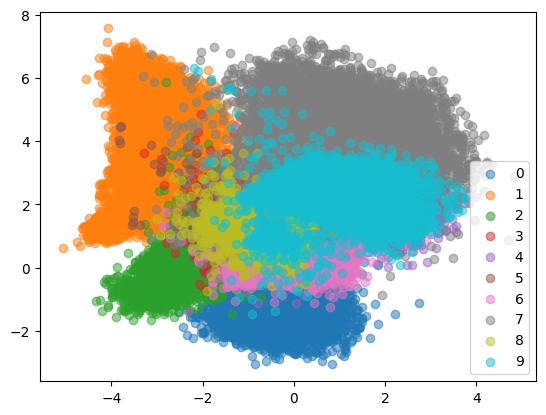

In [30]:
plot_latent_space_with_labels(
    num_classes=10,
    data_loader=train_loader,
    model=model,
    device=device)

plt.legend()
plt.show()

In [ ]:
import os
save_path = '/content/drive/My Drive/models/autoencoder/'
# os.makedirs(save_path, exist_ok=True)

torch.save(model.state_dict(), save_path + 'autoencoder.pt')
torch.save(optimizer.state_dict(), save_path + 'optimizer.pt')


In [ ]:
import json


# Assuming these lists already exist
training_stats = {
   "log_dict":log_dict
}

save_path = '/content/drive/My Drive/models/autoencoder/'
# os.makedirs(save_path, exist_ok=True)

with open(save_path + 'training_stats.json', 'w') as f:
    json.dump(training_stats, f, indent=4)
